### Setup: Imports, Configuration & Helper Functions
This cell loads all required libraries, defines the IEEE 39-bus network configuration, weather parameters, generator cost data, and helper functions for data parsing. This is the foundation that keeps all later comparisons (OPF vs COPF vs WASOPF) consistent and reproducible.

Install Python dependencies:
pip install -r requirements.txt

Note: This project also requires the IPOPT solver to be installed separately.
### Install IPOPT

#### Mac (brew)
brew install ipopt

#### Ubuntu
sudo apt-get install coinor-libipopt-dev

#### Conda (recommended)
conda install -c conda-forge ipopt

In [1]:
from pyomo.environ import SolverFactory

solver = SolverFactory('ipopt')

if not solver.available():
    raise RuntimeError("IPOPT solver is not installed. Please install it before running.")

In [2]:
"""
WASOPF: Weather-Adaptive Sequential Optimal Power Flow
================================================================
IEEE 39-Bus New England System  |  Pyomo + IPOPT (NLP)

Implements fully coupled Electro-Thermal AC-OPF, where line 
resistance R_ij is a function of conductor temperature T_c. The 
value of T_c is evaluated dynamically using Newton-Raphson on the 
heat balance equation inside a sequential solver loop.

MDI calculation is based on the Lavdas Ventilation Index.
"""

import os
import sys
import io
import warnings
import math
import numpy as np
import pandas as pd
import xarray as xr
import pandapower.networks as pn
import pyomo.environ as pyo
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

if sys.stdout.encoding and sys.stdout.encoding.lower() != "utf-8":
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding="utf-8", errors="replace")
    sys.stderr = io.TextIOWrapper(sys.stderr.buffer, encoding="utf-8", errors="replace")

warnings.filterwarnings("ignore")

if "__file__" in globals():
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
else:
    SCRIPT_DIR = os.getcwd()

# ================================================================
#  Configuration
# ================================================================

CONFIG = {
    "weather_csv": os.path.join(SCRIPT_DIR, "WASOPF_bus_weather_1day.csv"),
    "weather_files": [
        os.path.join(SCRIPT_DIR, "9410557632afc6881cad054ebdfb835", "data_stream-oper_stepType-instant.nc"),
        os.path.join(SCRIPT_DIR, "9410557632afc6881cad054ebdfb835", "data_stream-oper_stepType-accum.nc")
    ],
    "plot_dir": os.path.join(SCRIPT_DIR, "plots_wasopf"),
    
    "T_ref_C": 15.0,
    "alpha_resistance": 0.00393,
    
    # --- WA-C-OPF Tuned Penalty Lambdas ---
    "lambda_carbon": 5,   # Carbon penalty multiplier ($/tCO2)
    "lambda_pop": 0.0001,     # Population multiplier (1000 people adds 1x to the tax)
    "lambda_mdi": 15,        # MDI multiplier (15x penalty per MDI unit)
    "emission_factors": {
        "Coal": 0.82, "Gas": 0.49, "Wind": 0.00,
    },
    
    "eta_degradation": {
        "Coal": 0.004, "Gas": 0.010, "Wind": 0.000,
    },
    
    "gen_fuel_map": {
        31: "Coal", 33: "Coal", 37: "Coal",
        34: "Gas",  35: "Gas",  39: "Gas",
        30: "Wind", 32: "Wind", 36: "Wind", 38: "Wind"
    },
    
    # --- Hardcoded Population Density (People per sq km) ---
    "Pop_g": [15.0, 250.0, 20.0, 300.0, 4500.0, 5200.0, 10.0, 280.0, 18.0, 6000.0],
    
    "wind_buses": [30,32,36,38],
    "wind_capacity_mw": [126 ,1500 , 528, 278],
    
    "V_min": 0.94, "V_max": 1.06,
    "BASE_MVA": 100.0,
    "SLACK_BUS": 31,
    "SOLVER": "ipopt",
    "SOLVER_TOL": 1e-4,
    "SOLVER_MAX_ITER": 2000,
    "EXT_GRID_Q_MIN": -500.0, "EXT_GRID_Q_MAX": 500.0,
    "DEFAULT_I_MAX_KA": 2.0,
    
    # --- Real-World Generation Costs ---
    # Quadratic Cost A ($/MW^2h)
    "GEN_COST_A": [0.000, 0.0020, 0.000, 0.0025, 0.0040, 
                   0.0045, 0.000, 0.0030, 0.000, 0.0050],
    # Linear Cost B (Marginal fuel cost $/MWh)
    "GEN_COST_B": [0.0, 22.0, 0.0, 24.0, 45.0, 
                   48.0, 0.0, 25.0, 0.0, 50.0],
    # Constant Cost C (No-load cost $/hr)
    "GEN_COST_C": [0.0, 300.0, 0.0, 320.0, 150.0, 
                   160.0, 0.0, 350.0, 0.0, 140.0],
                   
    "conductor_diameter_m": 0.0281,
    "conductor_X_ref_ohm_per_km": 0.4,  # Typical 345kV tower reactance for length estimation
    "conductor_emissivity": 0.7,
    "solar_absorptivity": 0.5,
    "T_max_conductor_C": 100.0,
    "stefan_boltzmann": 5.67e-8,
    "required_weather_vars": ["t2m", "u10", "v10", "ssrd", "blh"],
}

# ================================================================
#  Weather & Preprocessing
# ================================================================

def load_network():
    net = pn.case39()
    return net

def parse_case39_data(net, config):
    ext = net.ext_grid.reset_index().rename(columns={"index": "uid"}).copy()
    ext["unit_type"] = "ext_grid"
    ext = ext[["uid", "bus", "unit_type", "min_p_mw", "max_p_mw", "min_q_mvar", "max_q_mvar"]]

    gen = net.gen.reset_index().rename(columns={"index": "uid"}).copy()
    gen["unit_type"] = "gen"
    gen = gen[["uid", "bus", "unit_type", "min_p_mw", "max_p_mw", "min_q_mvar", "max_q_mvar"]]

    gdf = pd.concat([ext, gen], ignore_index=True).sort_values("bus").reset_index(drop=True)

    gdf["bus1"] = gdf["bus"].astype(int) + 1
    fuel_map = config.get("gen_fuel_map", {})
    gdf["fuel_type"] = [fuel_map.get(int(b), "Gas") for b in gdf["bus1"].to_numpy()]
    gdf["alpha_g"] = gdf["fuel_type"].map(config["emission_factors"]).fillna(0.42)

    # Replaced CSV fetching with direct reading from CONFIG hardcoded array
    fb_pop = config.get("Pop_g", [0.0]*10)
    pop_list = []
    for i, row in gdf.iterrows():
        p_val = float(fb_pop[i]) if i < len(fb_pop) else 0.0
        pop_list.append(p_val)
    gdf["Pop_g"] = pop_list

    gdf["eta_g"] = gdf["fuel_type"].map(config["eta_degradation"]).fillna(0.01)

    gdf["pmin_mw"] = pd.to_numeric(gdf["min_p_mw"], errors="coerce").fillna(0.0)
    gdf["pmax_mw"] = pd.to_numeric(gdf["max_p_mw"], errors="coerce").fillna(2500.0)
    gdf["qmin_mvar"] = pd.to_numeric(gdf["min_q_mvar"], errors="coerce").fillna(config["EXT_GRID_Q_MIN"])
    gdf["qmax_mvar"] = pd.to_numeric(gdf["max_q_mvar"], errors="coerce").fillna(config["EXT_GRID_Q_MAX"])

    poly_map = {}
    if hasattr(net, "poly_cost") and len(net.poly_cost) > 0:
        for _, row in net.poly_cost.iterrows():
            poly_map[(str(row["et"]), int(row["element"]))] = (
                float(row.get("cp2_eur_per_mw2", 0.0)),
                float(row.get("cp1_eur_per_mw", 0.0)),
                float(row.get("cp0_eur", 0.0)),
            )

    fb_a = list(config.get("GEN_COST_A", []))
    fb_b = list(config.get("GEN_COST_B", []))
    fb_c = list(config.get("GEN_COST_C", []))
    cost_a, cost_b, cost_c = [], [], []
    for i, row in gdf.iterrows():
        key = (str(row["unit_type"]), int(row["uid"]))
        if key in poly_map:
            a_i, b_i, c_i = poly_map[key]
        else:
            a_i = float(fb_a[i]) if i < len(fb_a) else 0.0
            b_i = float(fb_b[i]) if i < len(fb_b) else 0.0
            c_i = float(fb_c[i]) if i < len(fb_c) else 0.0
        cost_a.append(a_i)
        cost_b.append(b_i)
        cost_c.append(c_i)

    gdf["cost_a"] = cost_a
    gdf["cost_b"] = cost_b
    gdf["cost_c"] = cost_c

    vmin_default = float(config["V_min"])
    vmax_default = float(config["V_max"])
    vmin_bus = np.full(len(net.bus), vmin_default)
    vmax_bus = np.full(len(net.bus), vmax_default)
    if "min_vm_pu" in net.bus.columns:
        min_vals = pd.to_numeric(net.bus["min_vm_pu"], errors="coerce").to_numpy()
        vmin_bus = np.where(np.isnan(min_vals), vmin_bus, min_vals)
    if "max_vm_pu" in net.bus.columns:
        max_vals = pd.to_numeric(net.bus["max_vm_pu"], errors="coerce").to_numpy()
        vmax_bus = np.where(np.isnan(max_vals), vmax_bus, max_vals)

    cfg_wind_buses = [int(b) for b in config.get("wind_buses", [])]
    cfg_wind_caps = [float(c) for c in config.get("wind_capacity_mw", [])]
    old_wind_map = {int(b): float(c) for b, c in zip(cfg_wind_buses, cfg_wind_caps)}
    pmax_by_bus = {int(row["bus"]): float(row["pmax_mw"]) for _, row in gdf.iterrows()}
    wind_buses = cfg_wind_buses
    wind_caps = []
    for i, bus in enumerate(wind_buses):
        if i < len(cfg_wind_caps):
            cap = cfg_wind_caps[i]
        else:
            pmax = float(pmax_by_bus.get(bus, 0.0))
            cap = pmax if pmax > 0.0 else old_wind_map.get(bus, 500.0)
        wind_caps.append(float(cap))

    runtime = {
        "V_min": float(np.min(vmin_bus)),
        "V_max": float(np.max(vmax_bus)),
        "V_min_bus": [float(v) for v in vmin_bus],
        "V_max_bus": [float(v) for v in vmax_bus],
        "BASE_MVA": float(getattr(net, "sn_mva", config["BASE_MVA"])),
        "SLACK_BUS": int(net.ext_grid.iloc[0]["bus"]) + 1 if len(net.ext_grid) > 0 else int(config["SLACK_BUS"]),
        "GEN_COST_A": [float(v) for v in cost_a],
        "GEN_COST_B": [float(v) for v in cost_b],
        "GEN_COST_C": [float(v) for v in cost_c],
        "wind_buses": wind_buses,
        "wind_capacity_mw": wind_caps,
    }
    return gdf, runtime


### Parsing Test: IEEE 39-Bus Network
This cell validates that the network and configuration were loaded correctly by parsing the IEEE 39-bus data and displaying key network statistics.

In [3]:
# Cell 2: focused parsing test for IEEE 39-bus

required_symbols = ["load_network", "parse_case39_data", "CONFIG"]
missing = [name for name in required_symbols if name not in globals()]
if missing:
    raise RuntimeError(
        f"Missing required symbols: {missing}. Run Cell 1 first."
    )

net = load_network()
gdf, runtime = parse_case39_data(net, CONFIG)

# Basic sanity checks
assert len(net.bus) == 39, f"Expected 39 buses, got {len(net.bus)}"
assert len(gdf) == len(net.ext_grid) + len(net.gen), (
    f"Parsed generator table size mismatch: {len(gdf)} vs {len(net.ext_grid) + len(net.gen)}"
)
assert "fuel_type" in gdf.columns, "Missing fuel_type column"
assert "pmax_mw" in gdf.columns, "Missing pmax_mw column"
assert "V_min" in runtime and "V_max" in runtime, "Missing voltage limits in runtime"

print("✅ Net39 loading + parsing successful")
print(f"Buses: {len(net.bus)} | Lines: {len(net.line)} | Loads: {len(net.load)}")
print(f"Parsed units: {len(gdf)} (ext_grid={len(net.ext_grid)}, gen={len(net.gen)})")
print(f"Runtime slack bus: {runtime['SLACK_BUS']}")
print(f"Runtime V-range: [{runtime['V_min']:.3f}, {runtime['V_max']:.3f}]")

display(gdf.head(10))

✅ Net39 loading + parsing successful
Buses: 39 | Lines: 35 | Loads: 21
Parsed units: 10 (ext_grid=1, gen=9)
Runtime slack bus: 31
Runtime V-range: [0.940, 1.060]


,uid,bus,unit_type,min_p_mw,max_p_mw,min_q_mvar,max_q_mvar,bus1,fuel_type,alpha_g,Pop_g,eta_g,pmin_mw,pmax_mw,qmin_mvar,qmax_mvar,cost_a,cost_b,cost_c
0,0,29,gen,0.0,1040.0,140.0,400.0,30,Wind,0.00,15.0,0.000,0.0,1040.0,140.0,400.0,0.01,0.3,0.2
1,0,30,ext_grid,0.0,646.0,-100.0,300.0,31,Coal,0.82,250.0,0.004,0.0,646.0,-100.0,300.0,0.01,0.3,0.2
2,1,31,gen,0.0,725.0,150.0,300.0,32,Wind,0.00,20.0,0.000,0.0,725.0,150.0,300.0,0.01,0.3,0.2
3,2,32,gen,0.0,652.0,0.0,250.0,33,Coal,0.82,300.0,0.004,0.0,652.0,0.0,250.0,0.01,0.3,0.2
4,3,33,gen,0.0,508.0,0.0,167.0,34,Gas,0.49,4500.0,0.010,0.0,508.0,0.0,167.0,0.01,0.3,0.2
5,4,34,gen,0.0,687.0,-100.0,300.0,35,Gas,0.49,5200.0,0.010,0.0,687.0,-100.0,300.0,0.01,0.3,0.2
6,5,35,gen,0.0,580.0,0.0,240.0,36,Wind,0.00,10.0,0.000,0.0,580.0,0.0,240.0,0.01,0.3,0.2
7,6,36,gen,0.0,564.0,0.0,250.0,37,Coal,0.82,280.0,0.004,0.0,564.0,0.0,250.0,0.01,0.3,0.2
8,7,37,gen,0.0,865.0,-150.0,300.0,38,Wind,0.00,18.0,0.000,0.0,865.0,-150.0,300.0,0.01,0.3,0.2
9,8,38,gen,0.0,1100.0,-100.0,300.0,39,Gas,0.49,6000.0,0.010,0.0,1100.0,-100.0,300.0,0.01,0.3,0.2


### Weather Loading Function
Defines `load_weather()` which reads the CSV weather file, validates required columns, and preprocesses hourly bus-level weather features (temperature, wind speed, solar irradiance, and MDI).

In [4]:
def load_weather(config):
    csv_path = config.get("weather_csv")
    if csv_path and os.path.isfile(csv_path):
        wdf = pd.read_csv(csv_path)
        required_base = {"time", "bus"}
        if not required_base.issubset(set(wdf.columns)):
            missing = sorted(required_base - set(wdf.columns))
            raise ValueError(f"Weather CSV missing required columns: {missing}")

        wdf["time"] = pd.to_datetime(wdf["time"])
        wdf = wdf.sort_values(["time", "bus"]).reset_index(drop=True)

        unique_times = sorted(wdf["time"].unique())
        if len(unique_times) < 24:
            raise ValueError(f"Expected at least 24 hourly timestamps, found {len(unique_times)}")
        unique_times = unique_times[:24]
        hour_map = {t: i for i, t in enumerate(unique_times)}
        wdf = wdf[wdf["time"].isin(unique_times)].copy()
        wdf["hour"] = wdf["time"].map(hour_map).astype(int)

        wdf["bus"] = wdf["bus"].astype(int)
        buses = sorted(wdf["bus"].unique())
        if len(buses) != 39:
            raise ValueError(f"Expected 39 buses in weather CSV, found {len(buses)}")

        counts = wdf.groupby("hour").size()
        if not (counts == 39).all():
            raise ValueError("Each hour must contain exactly 39 weather rows (one per bus)")

        if "T_a" not in wdf.columns:
            if "t2m" not in wdf.columns:
                raise ValueError("Weather CSV must include either 'T_a' or 't2m'")
            wdf["T_a"] = wdf["t2m"] - 273.15

        if "v_wind" not in wdf.columns:
            if not {"u10", "v10"}.issubset(set(wdf.columns)):
                raise ValueError("Weather CSV must include either 'v_wind' or both 'u10' and 'v10'")
            wdf["v_wind"] = np.sqrt(wdf["u10"]**2 + wdf["v10"]**2)

        if "solar_W" not in wdf.columns:
            if "ssrd" not in wdf.columns:
                raise ValueError("Weather CSV must include either 'solar_W' or 'ssrd'")
            wdf["solar_W"] = wdf["ssrd"] / 3600.0

        if "BLH" not in wdf.columns:
            if "blh" not in wdf.columns:
                raise ValueError("Weather CSV must include either 'BLH' or 'blh'")
            wdf["BLH"] = wdf["blh"]

        if "VI" not in wdf.columns:
            wdf["VI"] = wdf["v_wind"] * wdf["BLH"]
            # Normalize MDI 
            wdf["MDI"] = np.minimum(wdf["VI"], 6000) / 6000
            

        return wdf[["hour", "time", "bus", "T_a", "v_wind", "solar_W", "BLH", "VI", "MDI"]].copy()

    if "weather_files" in config:
        ds = xr.merge([xr.open_dataset(f) for f in config["weather_files"]])
    else:
        ds = xr.open_dataset(config["weather_file"])
    req = config["required_weather_vars"]
    time_dim = "time" if "time" in ds.dims else ("valid_time" if "valid_time" in ds.dims else list(ds.dims)[0])
    w = ds[req].isel({time_dim: slice(0, 24)})
    lat = "lat" if "lat" in w.dims else "latitude"
    lon = "lon" if "lon" in w.dims else "longitude"
    wa = w.mean(dim=[lat, lon])

    # Lavdas Ventilation Index logic
    v_wind = np.sqrt(wa["u10"].values**2 + wa["v10"].values**2)
    blh = wa["blh"].values
    v_wind = np.maximum(v_wind, 0.1) # prevent exactly 0
    blh = np.maximum(blh, 10.0)

    VI = v_wind * blh
    MDI = np.minimum(VI, 6000) / 6000

    wdf = pd.DataFrame({
        "hour": np.arange(24),
        "T_a": wa["t2m"].values - 273.15,
        "v_wind": v_wind,
        "solar_W": wa["ssrd"].values / 3600.0,
        "BLH": blh,
        "VI": VI,
        "MDI": MDI
    })
    return wdf

wdf=load_weather(CONFIG)
wdf


,hour,time,bus,T_a,v_wind,solar_W,BLH,VI,MDI
0,0,2025-07-04 00:00:00,0,19.819770,5.587204,63.086855,102.789356,574.305130,0.044097
1,0,2025-07-04 00:00:00,1,21.848779,3.638243,61.621284,60.079175,218.582652,0.016784
2,0,2025-07-04 00:00:00,2,19.387927,4.474987,55.506198,147.135491,658.429455,0.050557
3,0,2025-07-04 00:00:00,3,18.629527,3.515557,38.564778,425.202507,1494.823779,0.114779
4,0,2025-07-04 00:00:00,4,16.597770,5.478060,44.338865,189.951126,1040.563624,0.079899
...,...,...,...,...,...,...,...,...,...
931,23,2025-07-04 23:00:00,34,19.569530,3.743455,229.969480,938.981819,3515.036082,0.269899
932,23,2025-07-04 23:00:00,35,23.251714,2.766215,240.223977,387.737543,1072.565374,0.082356
933,23,2025-07-04 23:00:00,36,20.088954,4.085973,237.031919,210.996628,862.126470,0.066198
934,23,2025-07-04 23:00:00,37,21.834021,5.632118,255.429720,215.591963,1214.239287,0.093234


### Weather Data Quick Inspection
Displays processed weather data samples and hourly coverage to verify the weather preprocessing pipeline produced valid, complete data.

In [5]:
# Quick hook: how processed weather data looks
if "wdf" not in globals():
    raise RuntimeError("Run the weather loading cell above first.")

print("Processed weather sample (first 10 rows):")
display(wdf.head(10))

print("\nHourly coverage check (rows per hour):")
display(wdf.groupby("hour").size().rename("rows_per_hour").head())

Processed weather sample (first 10 rows):


,hour,time,bus,T_a,v_wind,solar_W,BLH,VI,MDI
0,0,2025-07-04,0,19.819770,5.587204,63.086855,102.789356,574.305130,0.044097
1,0,2025-07-04,1,21.848779,3.638243,61.621284,60.079175,218.582652,0.016784
2,0,2025-07-04,2,19.387927,4.474987,55.506198,147.135491,658.429455,0.050557
3,0,2025-07-04,3,18.629527,3.515557,38.564778,425.202507,1494.823779,0.114779
4,0,2025-07-04,4,16.597770,5.478060,44.338865,189.951126,1040.563624,0.079899
5,0,2025-07-04,5,17.725614,0.564110,36.283889,201.769677,113.820376,0.008740
6,0,2025-07-04,6,16.028854,2.188576,54.407441,81.844338,179.122545,0.013754
7,0,2025-07-04,7,17.663659,6.258523,61.312755,184.330386,1153.635880,0.088581
8,0,2025-07-04,8,18.043469,6.134045,55.331546,161.452349,990.355945,0.076044
9,0,2025-07-04,9,15.789062,2.822863,30.376127,422.784673,1193.463149,0.091639



Hourly coverage check (rows per hour):


hour
0    39
1    39
2    39
3    39
4    39
Name: rows_per_hour, dtype: int64

### Weather Hour-Bus Frame Selector
Defines `weather_hour_bus_frame()` which extracts and indexes weather data for a specific hour, making it easy to look up bus-level weather conditions during optimization.

In [6]:
def weather_hour_bus_frame(weather_df, hour):
    if {"hour", "bus"}.issubset(set(weather_df.columns)):
        hdf = weather_df[weather_df["hour"] == hour].copy()
        if hdf.empty:
            raise ValueError(f"No weather rows found for hour={hour}")
        return hdf.set_index("bus")

    if hour < 0 or hour >= len(weather_df):
        raise ValueError(f"Hour index {hour} out of range for weather data")
    row = weather_df.iloc[[hour]].copy()
    row["bus"] = 0
    return row.set_index("bus")

### Hour-0 Weather Snapshot
Displays key weather statistics (temperature, wind speed, solar irradiance, MDI) for hour 0 as a quick sanity check on the weather data ranges.

In [7]:
# Hour-0 weather hook: concise stats + sample rows
wdf_hour0 = weather_hour_bus_frame(wdf, 0)

print(f"Hour-0 rows: {len(wdf_hour0)}")
print("Hour-0 key ranges:")
summary = pd.DataFrame({
    "min": wdf_hour0[["T_a", "v_wind", "solar_W", "MDI"]].min(),
    "max": wdf_hour0[["T_a", "v_wind", "solar_W", "MDI"]].max(),
    "mean": wdf_hour0[["T_a", "v_wind", "solar_W", "MDI"]].mean(),
})
display(summary)

print("\nSample weather rows (first 8 buses):")
display(wdf_hour0.reset_index().head(8))

Hour-0 rows: 39
Hour-0 key ranges:


,min,max,mean
T_a,14.733091,23.207979,18.338736
v_wind,0.025899,9.440989,3.616838
solar_W,18.266383,84.887182,57.501730
MDI,0.000245,0.390019,0.098986



Sample weather rows (first 8 buses):


,bus,hour,time,T_a,v_wind,solar_W,BLH,VI,MDI
0,0,0,2025-07-04,19.819770,5.587204,63.086855,102.789356,574.305130,0.044097
1,1,0,2025-07-04,21.848779,3.638243,61.621284,60.079175,218.582652,0.016784
2,2,0,2025-07-04,19.387927,4.474987,55.506198,147.135491,658.429455,0.050557
3,3,0,2025-07-04,18.629527,3.515557,38.564778,425.202507,1494.823779,0.114779
4,4,0,2025-07-04,16.597770,5.478060,44.338865,189.951126,1040.563624,0.079899
5,5,0,2025-07-04,17.725614,0.564110,36.283889,201.769677,113.820376,0.008740
6,6,0,2025-07-04,16.028854,2.188576,54.407441,81.844338,179.122545,0.013754
7,7,0,2025-07-04,17.663659,6.258523,61.312755,184.330386,1153.635880,0.088581


### Line Weather Input Computation
Defines `line_weather_inputs()` which computes the average weather conditions (temperature, wind speed, solar loading) at each transmission line by averaging conditions at both endpoint buses.

In [8]:
def line_weather_inputs(hour_bus_df, from_bus, to_bus):
    ta = 0.5 * (float(hour_bus_df.at[from_bus, "T_a"]) + float(hour_bus_df.at[to_bus, "T_a"]))
    vw = 0.5 * (float(hour_bus_df.at[from_bus, "v_wind"]) + float(hour_bus_df.at[to_bus, "v_wind"]))
    sw = 0.5 * (float(hour_bus_df.at[from_bus, "solar_W"]) + float(hour_bus_df.at[to_bus, "solar_W"]))
    return ta, max(vw, 0.1), max(sw, 0.0)



### Generator Thermal Degradation
Defines `compute_degradation()` which calculates the degradation matrix `D_matrix[g, h]`. Values near 1.0 imply low thermal penalty; larger values indicate stronger weather-driven derating pressure. This directly impacts dispatch decisions in weather-sensitive runs.

In [9]:
def compute_degradation(gdf, weather_df, config):
    eta = gdf["eta_g"].values.reshape(-1, 1)

    if {"hour", "bus"}.issubset(set(weather_df.columns)):
        n_hours = int(weather_df["hour"].max()) + 1
        n_gens = len(gdf)
        D = np.ones((n_gens, n_hours))
        buses = gdf["bus"].to_numpy()
        for t in range(n_hours):
            hour_df = weather_hour_bus_frame(weather_df, t)
            T_a_g = np.array([float(hour_df.at[b, "T_a"]) for b in buses])
            excess = np.maximum(0.0, T_a_g - config["T_ref_C"])
            D[:, t] = (1.0 + eta[:, 0] * excess)
        return D

    T_a = weather_df["T_a"].values
    excess = np.maximum(0.0, T_a - config["T_ref_C"])
    return 1.0 + eta * excess.reshape(1, -1)
D_matrix = compute_degradation(gdf, wdf, CONFIG)
print("Degradation matrix shape:", D_matrix.shape)
display(pd.DataFrame(D_matrix, columns=[f"Hour {i}" for i in range(D_matrix.shape[1])], index=gdf["uid"]))

Degradation matrix shape: (10, 24)


,Hour 0,Hour 1,Hour 2,Hour 3,Hour 4,Hour 5,Hour 6,Hour 7,Hour 8,Hour 9,...,Hour 14,Hour 15,Hour 16,Hour 17,Hour 18,Hour 19,Hour 20,Hour 21,Hour 22,Hour 23
uid,,,,,,,,,,,,,,,,,,,,,
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
0,1.011463,1.007921,1.005764,1.005741,1.007302,1.008854,1.008710,1.007962,1.006290,1.005836,...,1.020522,1.023392,1.026096,1.026700,1.027808,1.022811,1.018316,1.022803,1.018331,1.015555
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,1.006186,1.004428,1.000402,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.005124,1.006199,1.011291,1.014455,1.018903,1.021217,1.023603,1.026018,1.025284,1.023768
3,1.052427,1.039285,1.026174,1.018118,1.013046,1.004756,1.000000,1.000000,1.000000,1.000000,...,1.037813,1.048653,1.053932,1.059811,1.067103,1.071074,1.078240,1.080257,1.084001,1.079891
4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.005282,1.026658,1.039285,1.042828,1.044088,1.046658,1.045695
5,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,1.023333,1.023373,1.022882,1.022561,1.021352,1.020912,1.021693,1.021522,1.020983,1.020476,...,1.019706,1.019967,1.020241,1.020678,1.020645,1.020269,1.019694,1.019470,1.020289,1.020356
7,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Wind Power Output Computation
Defines `compute_wind_output()` which calculates available wind generation at each wind bus using a piecewise wind power curve (cut-in, rated, cut-out speeds). This is the weather-constrained renewable envelope seen by the optimizer.

In [10]:
def compute_wind_output(weather_df, config):
    caps = np.array(config["wind_capacity_mw"]).reshape(-1, 1)
    v_cut_in = 2.5
    v_rated = 9.0
    v_cut_out = 25.0

    if {"hour", "bus"}.issubset(set(weather_df.columns)):
        n_hours = int(weather_df["hour"].max()) + 1
        n_wind = len(config["wind_buses"])
        v = np.zeros((n_wind, n_hours))
        for t in range(n_hours):
            hour_df = weather_hour_bus_frame(weather_df, t)
            for i, bus in enumerate(config["wind_buses"]):
                v[i, t] = float(hour_df.at[bus, "v_wind"])
        
        # Linear approximation between cut-in and rated
        cf = np.clip((v - v_cut_in) / (v_rated - v_cut_in), 0.0, 1.0)
        cf[v > v_cut_out] = 0.0  # Safety shutdown
        return caps * cf

    # Fallback for flat weather arrays
    v = weather_df["v_wind"].values
    cf = np.clip((v - v_cut_in) / (v_rated - v_cut_in), 0.0, 1.0)
    cf[v > v_cut_out] = 0.0
    return caps * cf.reshape(1, -1)

### Wind Availability Summary
Displays wind output totals, peak hour, and sample data. If available wind is high but dispatched wind is low later, that usually points to network constraints, thermal constraints, or objective trade-offs.

In [11]:
# Wind availability insight cell: totals + peak hour + sample
wind_output = compute_wind_output(wdf, CONFIG)

wind_output_df = pd.DataFrame(
    wind_output.T,
    columns=[f"Bus {b}" for b in CONFIG["wind_buses"]],
    index=np.arange(wind_output.shape[1])
)
wind_output_df.index.name = "Hour"
wind_output_df["Total_Wind_MW"] = wind_output_df.sum(axis=1)

print(f"Average hourly available wind (MW): {wind_output_df['Total_Wind_MW'].mean():.2f}")
peak_hour = int(wind_output_df["Total_Wind_MW"].idxmax())
print(f"Peak wind availability hour: {peak_hour} (MW={wind_output_df.loc[peak_hour, 'Total_Wind_MW']:.2f})")

print("\nHourly wind sample (first 10 hours):")
display(wind_output_df.head(10))

Average hourly available wind (MW): 589.20
Peak wind availability hour: 1 (MW=837.81)

Hourly wind sample (first 10 hours):


,Bus 30,Bus 32,Bus 36,Bus 38,Total_Wind_MW
Hour,,,,,
0,0.000000,42.745392,528.000000,192.338254,763.083646
1,0.000000,132.939832,528.000000,176.873409,837.813241
2,0.000000,200.323404,287.463604,167.080395,654.867402
3,0.000000,173.894334,208.873037,203.307645,586.075016
4,3.127408,164.965678,374.423600,166.109953,708.626639
5,1.831247,137.229435,395.124632,142.264492,676.449806
6,0.000000,107.009961,369.429481,196.542969,672.982411
7,7.423929,74.660484,352.197144,163.854616,598.136172
8,15.374894,48.882071,298.767179,48.783093,411.807236


### Newton-Raphson Conductor Temperature Solver
Defines the Newton-Raphson iterative solver for conductor temperature `T_c`. This is the core of the electro-thermal coupling — it solves the heat balance equation to determine how conductor temperature changes with current flow and ambient weather conditions.

In [12]:
def newton_raphson_Tc(I_amp_static, R_ohm_per_km, D, eps, a_s, alpha_R, 
                    T_a_ref_C=25.0, v_wind_ref=0.6, solar_W_ref=0.0, T_ref_C=25.0):
    """
    Reverse-engineers the design T_max by solving the heat balance equation 
    assuming standard reference weather and the static max current.
    Everything is calculated strictly in Watts per meter (W/m).
    """
    sigma = 5.67e-8
    T_a = T_a_ref_C + 273.15
    T_ref = T_ref_C + 273.15
    
    # Convert resistance from Ohms/km to Ohms/meter
    R_ohm_per_m = R_ohm_per_km / 1000.0
    
    # Simplified convection coefficient
    h_v = 7.0 + 3.8 * v_wind_ref
    
    T_c = T_a + 10.0 # Initial guess
    
    for _ in range(30):
        # 1. Calculate Resistance at current guess T_c (Ohms/m)
        R_tc = R_ohm_per_m * (1.0 + alpha_R * (T_c - T_ref))
        
        # 2. Ohmic Heating (W/m) = I^2 * R
        q_j = (I_amp_static**2) * R_tc
        
        # 3. Cooling & Solar Heating (W/m)
        q_c = h_v * np.pi * D * (T_c - T_a)
        q_r = eps * sigma * np.pi * D * (T_c**4 - T_a**4)
        q_s = a_s * solar_W_ref * D
        
        # Heat Balance Residual
        f = q_c + q_r - q_s - q_j
        
        # Derivative with respect to T_c
        dq_c_dT = h_v * np.pi * D
        dq_r_dT = 4.0 * eps * sigma * np.pi * D * (T_c**3)
        dq_j_dT = (I_amp_static**2) * R_ohm_per_m * alpha_R
        
        df = dq_c_dT + dq_r_dT - dq_j_dT
        
        if abs(df) < 1e-9:
            break
            
        dT = -f / df
        T_c += dT
        
        if abs(dT) < 1e-3:
            break
            
    return T_c # Returns in Kelvin

### Dynamic Line Rating (DLR) Calculation
Defines `get_dlr_I_max_pu()` which computes weather-dependent maximum current ratings for each line. DLR allows higher power transfer when weather conditions are favorable (cool, windy) and reduces ratings during hot, calm conditions — a key WASOPF feature.

In [13]:
def get_dlr_I_max_pu(net, hour_bus_df, config, dynamic_tmax=True):
    I_max_pu_list = []
    
    D = config["conductor_diameter_m"]
    eps = config["conductor_emissivity"]
    a_s = config["solar_absorptivity"]
    sigma = config["stefan_boltzmann"]
    alpha_R = config["alpha_resistance"]
    T_ref_K = config["T_ref_C"] + 273.15
    X_ref = config.get("conductor_X_ref_ohm_per_km", 0.4)

    for _, ln in net.line.iterrows():
        fb, tb = int(ln["from_bus"]), int(ln["to_bus"])
        
        # Fetch weather for this line at this hour
        T_a_C, v_wind, solar = line_weather_inputs(hour_bus_df, fb, tb)
        T_a_K = T_a_C + 273.15
        
        vn_kv = float(net.bus.at[fb, "vn_kv"])
        ib = config["BASE_MVA"] * 1000.0 / (np.sqrt(3) * vn_kv)
        
        ik = float(ln["max_i_ka"]) if not pd.isna(ln["max_i_ka"]) else config["DEFAULT_I_MAX_KA"]
        I_amp_static = ik * 1000.0
        
        par = float(ln["parallel"]) if float(ln["parallel"]) != 0 else 1.0
        
        # --- Per-line physical conductor R ---
        # pandapower r_ohm_per_km is system-level (= R_pu * Z_base at length_km=1)
        # Derive physical conductor R using X-based line length estimation
        R_total_ohm = float(ln["r_ohm_per_km"]) * float(ln["length_km"]) / par
        X_total_ohm = float(ln["x_ohm_per_km"]) * float(ln["length_km"]) / par
        L_est_km = max(X_total_ohm / X_ref, 1.0)
        R_conductor_ohm_per_km = R_total_ohm / L_est_km
        
        # 1. Determine T_max
        if dynamic_tmax:
            T_max_K = newton_raphson_Tc(I_amp_static, R_conductor_ohm_per_km, D, eps, a_s, alpha_R, 
                                      T_a_ref_C=T_a_C, v_wind_ref=v_wind, solar_W_ref=solar, T_ref_C=config["T_ref_C"])
            # Safety: if NR produces unphysical result, fallback to static T_max
            if np.isnan(T_max_K) or np.isinf(T_max_K) or T_max_K < T_a_K:
                T_max_K = config["T_max_conductor_C"] + 273.15
        else:
            T_max_K = config["T_max_conductor_C"] + 273.15
            
        # 2. Calculate Maximum Heat Dissipation AT T_max given CURRENT weather
        R_phys_per_m = R_conductor_ohm_per_km / 1000.0
        h_v = 7.0 + 3.8 * v_wind
        q_c_max = h_v * np.pi * D * (T_max_K - T_a_K)
        q_r_max = eps * sigma * np.pi * D * (T_max_K**4 - T_a_K**4)
        q_s = a_s * solar * D
        
        # Max allowable Ohmic heating (W/m)
        q_j_allowable = max(q_c_max + q_r_max - q_s, 1.0)
        
        # 3. Calculate Resistance at T_max (using physical conductor R)
        R_at_Tmax = R_phys_per_m * (1.0 + alpha_R * (T_max_K - T_ref_K))
        
        # 4. Calculate Dynamic I_max (Amps) and convert to per-unit
        if R_at_Tmax > 1e-12:
            I_dlr_amps = np.sqrt(q_j_allowable / R_at_Tmax)
        else:
            I_dlr_amps = I_amp_static  # Fallback to static limit
        
        I_max_pu_list.append(I_dlr_amps / ib)

    return I_max_pu_list

### Dynamic Admittance Matrix Construction
Defines `build_ybus_dynamic()` which builds the bus admittance matrix Y-bus using temperature-dependent line resistances. This matrix is fundamental to the AC power flow equations.

In [14]:
def build_ybus_dynamic(net, R_ij_pu_list):
    base = CONFIG["BASE_MVA"]
    nb = len(net.bus)
    Y = np.zeros((nb, nb), dtype=complex)

    for idx, ln in net.line.iterrows():
        fb, tb = int(ln["from_bus"]), int(ln["to_bus"])
        par = float(ln["parallel"]) if float(ln["parallel"]) != 0 else 1.0
        
        vn = float(net.bus.at[fb, "vn_kv"])
        zb = vn**2 / base
        
        r_pu = R_ij_pu_list[idx]
        x_ohm = float(ln["x_ohm_per_km"]) * float(ln["length_km"]) / par
        x_pu = x_ohm / zb
        
        zpu = complex(r_pu, x_pu)
        if abs(zpu) < 1e-12: continue
        ys = 1.0 / zpu
        
        c_nf = float(ln["c_nf_per_km"]) * float(ln["length_km"]) * par
        bc_pu = 2 * np.pi * 60.0 * c_nf * 1e-9 * zb
        ysh = complex(0, bc_pu / 2)
        
        Y[fb, fb] += ys + ysh
        Y[tb, tb] += ys + ysh
        Y[fb, tb] -= ys
        Y[tb, fb] -= ys

    for _, tf in net.trafo.iterrows():
        hv, lv = int(tf["hv_bus"]), int(tf["lv_bus"])
        sn = float(tf["sn_mva"])
        vk = float(tf["vk_percent"])
        vkr = float(tf["vkr_percent"])
        z_mag = (vk / 100) * (base / sn)
        r_t = (vkr / 100) * (base / sn)
        x_t = math.sqrt(max(z_mag**2 - r_t**2, 0))
        zt = complex(r_t, x_t)
        if abs(zt) < 1e-12: continue
        
        tp = float(tf.get("tap_pos", 0)) if not pd.isna(tf.get("tap_pos", np.nan)) else 0.0
        ts = float(tf.get("tap_step_percent", 0)) if not pd.isna(tf.get("tap_step_percent", np.nan)) else 0.0
        tn = float(tf.get("tap_neutral", 0)) if not pd.isna(tf.get("tap_neutral", np.nan)) else 0.0
        tau = 1.0 + (tp - tn) * ts / 100
        if abs(tau) < 1e-6:
            tau = 1.0
            
        yt = 1.0 / zt
        Y[hv, hv] += yt / tau**2
        Y[lv, lv] += yt
        Y[hv, lv] -= yt / tau
        Y[lv, hv] -= yt / tau

    return Y

### OPF Model Builder (Pyomo)
Defines `build_opf()` which constructs the full AC Optimal Power Flow model in Pyomo. Supports three modes: OPF (cost-only), COPF (carbon-constrained), and WASOPF (weather-adaptive with DLR, degradation, and MDI-based environmental weighting).

In [15]:
import numpy as np
import pandas as pd
import pyomo.environ as pyo
import math
import os

def build_opf(net, gdf, ybus, mdi_g, D_g_t, I_max_pu_list, wind_inject, R_ij_pu_list, mode="WASOPF", CONFIG=None):
    base = CONFIG["BASE_MVA"]
    nb = len(net.bus)
    ng = len(gdf)
    
    # ---------------------------------------------------------
    # 1. Pre-Processing & Sparsity Mapping
    # ---------------------------------------------------------
    lp = np.zeros(nb)
    lq = np.zeros(nb)
    for _, ld in net.load.iterrows():
        b = int(ld["bus"])
        lp[b] += float(ld["p_mw"])
        lq[b] += float(ld["q_mvar"])
    lp_pu = lp / base
    lq_pu = lq / base

    gbus = gdf["bus"].values.tolist()
    gat = {b: [] for b in range(nb)}
    for g in range(ng):
        gat[gbus[g]].append(g)

    G = ybus.real
    B = ybus.imag
    
    # Sparsity mapping: Only store connected buses to prevent dense NLP explosion
    connected_buses = {i: [] for i in range(nb)}
    for i in range(nb):
        for j in range(nb):
            if abs(G[i, j]) > 1e-8 or abs(B[i, j]) > 1e-8:
                connected_buses[i].append(j)

    m = pyo.ConcreteModel()
    m.B = pyo.Set(initialize=range(nb))
    m.G = pyo.Set(initialize=range(ng))
    m.L = pyo.Set(initialize=range(len(net.line)))

    # ---------------------------------------------------------
    # 2. Generator Limits & Variables
    # ---------------------------------------------------------
    pmin_mw = gdf["pmin_mw"].to_numpy(dtype=float)
    pmax_mw = gdf["pmax_mw"].to_numpy(dtype=float)

    pmax_dyn = [2500.0 / base] * ng
    pmin_dyn = [0.0] * ng
    for g in range(ng):
        pmax_g = float(pmax_mw[g]) if not np.isnan(pmax_mw[g]) else 2500.0
        pmin_g = float(pmin_mw[g]) if not np.isnan(pmin_mw[g]) else 0.0
        
        # Apply Thermal Degradation Penalty (Wait to zero out negative capacities)
        pmax_dyn[g] = (pmax_g / base) * max(2.0 - D_g_t[g], 0.0)
        pmin_dyn[g] = pmin_g / base
        
        if gbus[g] in wind_inject:
            pmax_dyn[g] = wind_inject[gbus[g]] / base

        if pmin_dyn[g] > pmax_dyn[g]:
            pmin_dyn[g] = pmax_dyn[g]

    m.Pg = pyo.Var(m.G, bounds=lambda _, g: (pmin_dyn[g], pmax_dyn[g]), initialize=lambda _, g: 0.5 * (pmin_dyn[g] + pmax_dyn[g]))
    
    qmin = gdf["qmin_mvar"].to_numpy(dtype=float).tolist()
    qmax = gdf["qmax_mvar"].to_numpy(dtype=float).tolist()
    for g in range(ng):
        if pd.isna(qmin[g]): qmin[g] = CONFIG["EXT_GRID_Q_MIN"]
        if pd.isna(qmax[g]): qmax[g] = CONFIG["EXT_GRID_Q_MAX"]
        qmin[g] = qmin[g] / base
        qmax[g] = qmax[g] / base

    m.Qg = pyo.Var(m.G, bounds=lambda _, g: (qmin[g], qmax[g]), initialize=lambda _, g: 0.5 * (qmin[g] + qmax[g]))

    # ---------------------------------------------------------
    # 3. Voltage Variables
    # ---------------------------------------------------------
    vmin_bus = np.array(CONFIG.get("V_min_bus", []), dtype=float)
    vmax_bus = np.array(CONFIG.get("V_max_bus", []), dtype=float)
    if len(vmin_bus) != nb or len(vmax_bus) != nb:
        vmin_bus = np.full(nb, float(CONFIG["V_min"]))
        vmax_bus = np.full(nb, float(CONFIG["V_max"]))

    m.V = pyo.Var(m.B, bounds=lambda _, b: (float(vmin_bus[b]), float(vmax_bus[b])), initialize=1.0)
    m.th = pyo.Var(m.B, bounds=(-np.pi, np.pi), initialize=0.0)

    # ---------------------------------------------------------
    # 4. Objective Function (Fix 1 & 3: Safe arrays and no hard caps)
    # ---------------------------------------------------------
    ca = gdf["cost_a"].to_numpy(dtype=float)
    cb = gdf["cost_b"].to_numpy(dtype=float)
    cc = gdf["cost_c"].to_numpy(dtype=float)
    alpha_g = gdf["alpha_g"].values
    pop_g = gdf["Pop_g"].values
    
    obj = 0
    for g in range(ng):
        P_mw = m.Pg[g] * base
        
        # Local multiplier ensures D_g_t array is never physically mutated
        d_factor = 1.0 if mode in ["COPF", "OPF"] else float(D_g_t[g])
        cost_g = d_factor * (ca[g] * P_mw**2 + cb[g] * P_mw + cc[g])
        
        obj += cost_g
        
        if mode in ["COPF", "WASOPF"]:
            lambda_popex = CONFIG["lambda_pop"] if mode == "WASOPF" else 0
            lambda_mdi = CONFIG.get("lambda_mdi", 1.0) if mode == "WASOPF" else 0

            weighting = (1.0 + lambda_popex * pop_g[g]) / (1.0 + lambda_mdi * max(float(mdi_g[g]), 0.0))
            emis_g = CONFIG["lambda_carbon"] * weighting * alpha_g[g] * P_mw
            obj += emis_g
            
    m.obj = pyo.Objective(expr=obj, sense=pyo.minimize)

    # ---------------------------------------------------------
    # 5. AC Power Flow Equality Constraints (Fix 2: Sparsity)
    # ---------------------------------------------------------
    def pb_p(model, i):
        pg = sum(model.Pg[g] for g in gat[i])
        return pg - lp_pu[i] == sum(
            model.V[i]*model.V[j]*(G[i,j]*pyo.cos(model.th[i]-model.th[j]) + B[i,j]*pyo.sin(model.th[i]-model.th[j]))
            for j in connected_buses[i] # Only iterates connected buses
        )
        
    def pb_q(model, i):
        qg = sum(model.Qg[g] for g in gat[i])
        return qg - lq_pu[i] == sum(
            model.V[i]*model.V[j]*(G[i,j]*pyo.sin(model.th[i]-model.th[j]) - B[i,j]*pyo.cos(model.th[i]-model.th[j]))
            for j in connected_buses[i] # Only iterates connected buses
        )
        
    m.pb_p = pyo.Constraint(m.B, rule=pb_p)
    m.pb_q = pyo.Constraint(m.B, rule=pb_q)

    slack_idx = int(net.ext_grid.iloc[0]["bus"])
    m.slack = pyo.Constraint(expr=m.th[slack_idx] == 0.0)

    # ---------------------------------------------------------
    # 6. Thermal Line Limits with Shunt Susceptance (Fix 4)
    # ---------------------------------------------------------
    lf, lt, l_g, l_b, l_bsh = [], [], [], [], []
    for l_idx, ln in net.line.iterrows():
        fb, tb = int(ln["from_bus"]), int(ln["to_bus"])
        lf.append(fb)
        lt.append(tb)
        
        par = float(ln["parallel"]) if float(ln["parallel"]) != 0 else 1.0
        length_km = float(ln["length_km"])
        vn_kv = float(net.bus.at[fb, "vn_kv"])
        zb = vn_kv**2 / base
        
        r_pu = R_ij_pu_list[l_idx]
        x_pu = (float(ln["x_ohm_per_km"]) * length_km / par) / zb
        
        d = r_pu**2 + x_pu**2
        if d > 1e-12:
            l_g.append(r_pu / d)
            l_b.append(-x_pu / d)
        else:
            l_g.append(0.0)
            l_b.append(0.0)
            
        c_nf = float(ln["c_nf_per_km"]) * length_km * par
        bsh_pu = 2 * np.pi * 60.0 * c_nf * 1e-9 * zb / 2.0  # Half line-charging
        l_bsh.append(bsh_pu)

    # Calculates total complex current leaving bus i towards bus j
    def clim_rule_from(model, l):
        i, j = lf[l], lt[l]
        g, b, bsh = l_g[l], l_b[l], l_bsh[l]
        if g == 0 and b == 0: return pyo.Constraint.Skip
        
        vi, vj = model.V[i], model.V[j]
        thi, thj = model.th[i], model.th[j]
        
        ir = g*(vi*pyo.cos(thi) - vj*pyo.cos(thj)) - b*(vi*pyo.sin(thi) - vj*pyo.sin(thj)) - bsh*vi*pyo.sin(thi)
        ii = g*(vi*pyo.sin(thi) - vj*pyo.sin(thj)) + b*(vi*pyo.cos(thi) - vj*pyo.cos(thj)) + bsh*vi*pyo.cos(thi)
        
        return ir**2 + ii**2 <= I_max_pu_list[l]**2

    # Calculates total complex current leaving bus j towards bus i (needed because shunts make I_ij != I_ji)
    def clim_rule_to(model, l):
        j, i = lf[l], lt[l] # Swap directions
        g, b, bsh = l_g[l], l_b[l], l_bsh[l]
        if g == 0 and b == 0: return pyo.Constraint.Skip
        
        vi, vj = model.V[i], model.V[j]
        thi, thj = model.th[i], model.th[j]
        
        ir = g*(vi*pyo.cos(thi) - vj*pyo.cos(thj)) - b*(vi*pyo.sin(thi) - vj*pyo.sin(thj)) - bsh*vi*pyo.sin(thi)
        ii = g*(vi*pyo.sin(thi) - vj*pyo.sin(thj)) + b*(vi*pyo.cos(thi) - vj*pyo.cos(thj)) + bsh*vi*pyo.cos(thi)
        
        return ir**2 + ii**2 <= I_max_pu_list[l]**2

    m.clim_from = pyo.Constraint(m.L, rule=clim_rule_from)
    m.clim_to = pyo.Constraint(m.L, rule=clim_rule_to)

    # Store configurations for extraction
    m._lf, m._lt, m._lg, m._lb = lf, lt, l_g, l_b
    m._base = base
    m._gbus = gbus
    return m

def solve_idaes(model, CONFIG):
    exe = os.path.join(os.path.expanduser("~"), "AppData", "Local", "idaes", "bin", "ipopt.exe")
    s = pyo.SolverFactory(CONFIG["SOLVER"], executable=exe) if os.path.isfile(exe) else pyo.SolverFactory(CONFIG["SOLVER"])
    
    s.options["tol"] = CONFIG["SOLVER_TOL"]
    s.options["max_iter"] = CONFIG["SOLVER_MAX_ITER"]
    s.options["print_level"] = 5
    s.options["acceptable_tol"] = 1e-4
    s.options["mu_strategy"] = "adaptive"
    
    # HSL linear solvers (ma27, ma57, ma86, ma97) drastically speed up sparse power flow matrices
    s.options["linear_solver"] = "mumps" 
    
    r = s.solve(model, tee=True)
    return str(r.solver.termination_condition)

def extract(model, net, gdf, wind_inject, CONFIG):
    base = model._base
    pmw = np.array([pyo.value(model.Pg[g])*base for g in range(len(gdf))])
    vpu = np.array([pyo.value(model.V[b]) for b in range(len(net.bus))])
    th = np.array([pyo.value(model.th[b]) for b in range(len(net.bus))])
    
    # Accurate transmission loss calculation using the series conductance
    loss = 0
    for l in range(len(model._lf)):
        i, j = model._lf[l], model._lt[l]
        g = model._lg[l]
        loss += g * (vpu[i]**2 + vpu[j]**2 - 2*vpu[i]*vpu[j]*np.cos(th[i]-th[j])) * base
        
    emis = float((gdf["alpha_g"].values * pmw).sum())
    wind_dispatched = sum(pmw[g] for g in range(len(gdf)) if model._gbus[g] in CONFIG["wind_buses"])
    
    return {"pmw": pmw, "v": vpu, "th": th, "cost": float(pyo.value(model.obj)),
            "gen_mw": float(pmw.sum()), "loss_mw": loss, "emis": emis,
            "wind_mw": wind_dispatched}

### Electro-Thermal Sequential Solver
Defines `solve_electro_thermal()` which implements the sequential loop: solve OPF → compute conductor temperatures → update line resistances → rebuild Y-bus → re-solve OPF until convergence. This is the core WASOPF algorithm.

In [16]:
import numpy as np
import pandas as pd

def solve_electro_thermal(net, gdf, wdf, hour, D_g_h, wind_inject, CONFIG, mode="WASOPF", dynamic_tmax=True):
    hour_bus_df = weather_hour_bus_frame(wdf, hour)
    slack_idx = int(net.ext_grid.iloc[0]["bus"])
    T_a_C = float(hour_bus_df.at[slack_idx, "T_a"])

    mdi_g = np.array([float(hour_bus_df.at[int(b), "MDI"]) for b in gdf["bus"].to_numpy()])

    if mode in ["OPF", "COPF"]:
        D_g_h = np.ones(len(gdf))
        mdi_g = np.ones(len(gdf))

    I_max_pu_list = get_dlr_I_max_pu(net, hour_bus_df, CONFIG, dynamic_tmax=(dynamic_tmax and mode == "WASOPF"))

    D = CONFIG["conductor_diameter_m"]
    eps = CONFIG["conductor_emissivity"]
    a_s = CONFIG["solar_absorptivity"]
    X_ref = CONFIG.get("conductor_X_ref_ohm_per_km", 0.4)

    max_iters = 1 if mode in ["OPF", "COPF"] else 15

    T_c_array = np.full(len(net.line), T_a_C)
    converged = False
    solve_failed = False
    last_iter = 0

    for iter_i in range(max_iters):
        last_iter = iter_i
        R_ij_pu_list = []
        
        for l_idx, ln in net.line.iterrows():
            fb = int(ln["from_bus"])
            vn_kv = float(net.bus.at[fb, "vn_kv"])
            Z_base = vn_kv**2 / CONFIG["BASE_MVA"]

            par = float(ln["parallel"]) if float(ln["parallel"]) != 0 else 1.0
            r_ohm = float(ln["r_ohm_per_km"]) * float(ln["length_km"]) / par

            if mode == "WASOPF":
                R_T = r_ohm * (1 + CONFIG["alpha_resistance"] * (T_c_array[l_idx] - CONFIG["T_ref_C"]))
            else:
                R_T = r_ohm  # OPF/COPF: no temperature adjustment
            R_ij_pu_list.append(R_T / Z_base)

        ybus = build_ybus_dynamic(net, R_ij_pu_list)
        
        m = build_opf(net, gdf, ybus, mdi_g, D_g_h, I_max_pu_list, wind_inject, R_ij_pu_list, mode=mode, CONFIG=CONFIG)
        
        tc = solve_idaes(m, CONFIG)
        
        if "optimal" not in tc.lower() and "acceptable" not in tc.lower():
            solve_failed = True
            break

        res = extract(m, net, gdf, wind_inject, CONFIG)

        # Skip NR temperature update for OPF/COPF — no thermal coupling
        if mode in ["OPF", "COPF"]:
            converged = True
            break

        max_dT = 0.0
        T_c_new = np.zeros(len(net.line))

        for l_idx, ln in net.line.iterrows():
            fb, tb = int(ln["from_bus"]), int(ln["to_bus"])
            T_a_line, v_wind_line, solar_line = line_weather_inputs(hour_bus_df, fb, tb)
            V_i, V_j = res["v"][fb], res["v"][tb]
            th_i, th_j = res["th"][fb], res["th"][tb]

            par = float(ln["parallel"]) if float(ln["parallel"]) != 0 else 1.0
            length_km = float(ln["length_km"])
            x_ohm = float(ln["x_ohm_per_km"]) * length_km / par
            vn_kv = float(net.bus.at[fb, "vn_kv"])
            
            Z_base = vn_kv**2 / CONFIG["BASE_MVA"]
            I_base = CONFIG["BASE_MVA"] * 1000.0 / (np.sqrt(3) * vn_kv)
            
            R_pu = R_ij_pu_list[l_idx]
            X_pu = x_ohm / Z_base

            # Calculate actual AC current magnitude algebraically
            g_ij = R_pu / (R_pu**2 + X_pu**2)
            b_ij = -X_pu / (R_pu**2 + X_pu**2)
            
            ir = g_ij*(V_i*np.cos(th_i) - V_j*np.cos(th_j)) - b_ij*(V_i*np.sin(th_i) - V_j*np.sin(th_j))
            ii = g_ij*(V_i*np.sin(th_i) - V_j*np.sin(th_j)) + b_ij*(V_i*np.cos(th_i) - V_j*np.cos(th_j))
            
            I_actual_pu = np.sqrt(ir**2 + ii**2)
            I_actual_amps = I_actual_pu * I_base

            # Derive physical conductor R for this specific line
            R_total_ohm = float(ln["r_ohm_per_km"]) * length_km / par
            X_total_ohm = float(ln["x_ohm_per_km"]) * length_km / par
            L_est_km = max(X_total_ohm / X_ref, 1.0)
            R_conductor_ohm_per_km = R_total_ohm / L_est_km

            T_new_K = newton_raphson_Tc(
                I_amp_static=I_actual_amps,
                R_ohm_per_km=R_conductor_ohm_per_km,
                D=D,
                eps=eps,
                a_s=a_s,
                alpha_R=CONFIG["alpha_resistance"],
                T_a_ref_C=T_a_line,
                v_wind_ref=v_wind_line,
                solar_W_ref=solar_line,
                T_ref_C=CONFIG["T_ref_C"]
            )

            T_new_C = T_new_K - 273.15
            # Safety: clamp to physical range
            T_new_C = max(T_new_C, T_a_line)
            T_c_new[l_idx] = T_new_C
            max_dT = max(max_dT, abs(T_new_C - T_c_array[l_idx]))

        T_c_array = T_c_new
        if max_dT < 0.2:
            converged = True
            break

    if not solve_failed:
        res["T_c"] = T_c_array
        res["I_max_pu"] = I_max_pu_list
        res["mdi_ref"] = float(hour_bus_df.at[slack_idx, "MDI"])
        res["mdi_g"] = mdi_g.copy()
        res["alpha_g"] = gdf["alpha_g"].to_numpy(dtype=float).copy()
        res["gen_buses"] = gdf["bus"].to_numpy(dtype=int).copy()
        res["fuel_types"] = gdf["fuel_type"].astype(str).tolist()
        return res, converged, last_iter

    print(f"    Hour {hour}: NLP Failed (Infeasible or Non-convergent)")
    return None, False, last_iter

### Full Simulation Runner
Defines `run_full_notebook_simulation()` — the experiment driver that runs OPF, COPF, and WASOPF hour-by-hour, stores compact + detailed outputs, and exports CSV artifacts for analysis.

In [17]:
# Notebook-only full simulation runner (OPF + COPF + WASOPF)
# Saves compact and detailed CSV outputs to ./final_results

import os
import numpy as np
import pandas as pd


def run_full_notebook_simulation(output_dir=None, dynamic_tmax=True):
    required = [
        "CONFIG", "load_network", "parse_case39_data", "load_weather", "compute_degradation",
        "compute_wind_output", "solve_electro_thermal", "weather_hour_bus_frame",
        "line_weather_inputs", "get_dlr_I_max_pu"
    ]
    missing = [name for name in required if name not in globals()]
    if missing:
        raise RuntimeError(f"Run the setup cells first. Missing: {missing}")

    if output_dir is None:
        output_dir = os.path.join(SCRIPT_DIR, "final_results") if "SCRIPT_DIR" in globals() else os.path.join(os.getcwd(), "final_results")

    os.makedirs(output_dir, exist_ok=True)

    pop_csv = os.path.join(SCRIPT_DIR, "bus_population_density.csv") if "SCRIPT_DIR" in globals() else os.path.join(os.getcwd(), "bus_population_density.csv")
    CONFIG["population_density_csv"] = pop_csv
    CONFIG["plot_dir"] = output_dir

    net = load_network()
    gdf, runtime_cfg = parse_case39_data(net, CONFIG)
    CONFIG.update(runtime_cfg)

    wdf = load_weather(CONFIG)
    if "VI" in wdf.columns and "MDI" not in wdf.columns:
        wdf["MDI"] = wdf["VI"]
    if "MDI" not in wdf.columns:
        wdf["MDI"] = 1.0

    n_hours = int(wdf["hour"].max()) + 1
    D_matrix = compute_degradation(gdf, wdf, CONFIG)
    wind_output = compute_wind_output(wdf, CONFIG)

    wind_gen_buses = set(gdf.loc[gdf["fuel_type"].astype(str).str.lower() == "wind", "bus"].astype(int).tolist())

    def _run_mode(mode, dyn_tmax):
        rows = []
        payloads = []

        for hour in range(n_hours):
            if mode in ["OPF", "COPF"]:
                D_g_h = np.ones(len(gdf))
            else:
                D_g_h = D_matrix[:, hour]

            wind_inject_raw = {
                int(CONFIG["wind_buses"][i]): float(wind_output[i, hour])
                for i in range(len(CONFIG["wind_buses"]))
            }
            wind_inject = {b: v for b, v in wind_inject_raw.items() if b in wind_gen_buses}

            # CORRECTION 1: Added CONFIG=CONFIG here
            res, converged, iterations = solve_electro_thermal(
                net=net,
                gdf=gdf,
                wdf=wdf,
                hour=hour,
                D_g_h=D_g_h,
                wind_inject=wind_inject,
                CONFIG=CONFIG,
                mode=mode,
                dynamic_tmax=dyn_tmax,
            )

            if res is None:
                rows.append({
                    "hour": hour, "mode": mode, "status": "failed", "converged": False,
                    "iterations": np.nan, "cost": np.nan, "gen_mw": np.nan, "loss_mw": np.nan,
                    "emis": np.nan, "wind_mw": np.nan, "mdi_ref": np.nan, "max_Tc": np.nan,
                })
                payloads.append(None)
                continue

            rows.append({
                "hour": hour,
                "mode": mode,
                "status": "ok",
                "converged": bool(converged or mode in ["OPF", "COPF"]),
                "iterations": int(iterations) + 1 if iterations is not None else np.nan,
                "cost": float(res["cost"]),
                "gen_mw": float(res["gen_mw"]),
                "loss_mw": float(res["loss_mw"]),
                "emis": float(res["emis"]),
                "wind_mw": float(res["wind_mw"]),
                "mdi_ref": float(res.get("mdi_ref", np.nan)),
                "max_Tc": float(np.max(res["T_c"])) if "T_c" in res else np.nan,
            })
            payloads.append(res)

        return pd.DataFrame(rows), payloads

    df_opf, payloads_opf = _run_mode("OPF", False)
    df_copf, payloads_copf = _run_mode("COPF", False)
    df_was, payloads_was = _run_mode("WASOPF", dynamic_tmax)

    hourly = pd.concat([df_opf, df_copf, df_was], ignore_index=True).sort_values(["mode", "hour"])

    compare = hourly.pivot(index="hour", columns="mode", values=["cost", "emis", "wind_mw", "loss_mw", "max_Tc", "mdi_ref"])
    compare.columns = [f"{metric}_{mode}" for metric, mode in compare.columns]
    compare = compare.reset_index()

    if "cost_WASOPF" in compare.columns and "cost_OPF" in compare.columns:
        compare["delta_cost_vs_OPF"] = compare["cost_WASOPF"] - compare["cost_OPF"]
    if "cost_WASOPF" in compare.columns and "cost_COPF" in compare.columns:
        compare["delta_cost_vs_COPF"] = compare["cost_WASOPF"] - compare["cost_COPF"]
    if "emis_WASOPF" in compare.columns and "emis_OPF" in compare.columns:
        compare["delta_emis_vs_OPF"] = compare["emis_WASOPF"] - compare["emis_OPF"]
    if "emis_WASOPF" in compare.columns and "emis_COPF" in compare.columns:
        compare["delta_emis_vs_COPF"] = compare["emis_WASOPF"] - compare["emis_COPF"]

    key_results = hourly.groupby("mode", dropna=False).agg(
        hours=("hour", "count"),
        successful_hours=("status", lambda s: int((s == "ok").sum())),
        avg_cost=("cost", "mean"),
        avg_emis=("emis", "mean"),
        avg_loss_mw=("loss_mw", "mean"),
        avg_wind_mw=("wind_mw", "mean"),
        max_Tc=("max_Tc", "max"),
    ).reset_index()

    gen_rows = []
    for hour, payload in enumerate(payloads_was):
        if payload is None:
            continue
        alpha = np.array(payload.get("alpha_g", []), dtype=float)
        p_mw = np.array(payload.get("pmw", []), dtype=float)
        mdi_g = np.array(payload.get("mdi_g", np.ones(len(alpha))), dtype=float)
        buses = np.array(payload.get("gen_buses", []), dtype=int)
        fuels = list(payload.get("fuel_types", []))

        n_g = min(len(alpha), len(p_mw), len(mdi_g), len(buses))
        for g in range(n_g):
            gen_rows.append({
                "hour": hour,
                "gen_index": g,
                "bus": int(buses[g]),
                "fuel_type": str(fuels[g]) if g < len(fuels) else "Unknown",
                "Pg_MW": float(p_mw[g]),
                "alpha_g": float(alpha[g]),
                "MDI_bus": float(mdi_g[g]),
                "Emission_g": float(alpha[g] * p_mw[g]),
            })
    gen_hourly = pd.DataFrame(gen_rows)

    line_rows = []
    
    # CORRECTION 2: Replaced mode="OPF" with CONFIG=CONFIG
    static_limits = get_dlr_I_max_pu(net, weather_hour_bus_frame(wdf, 0), CONFIG, dynamic_tmax=False)
    
    line_meta = net.line.reset_index().rename(columns={"index": "line_id"})[["line_id", "from_bus", "to_bus"]]

    for hour, payload in enumerate(payloads_was):
        if payload is None:
            continue
        hour_bus_df = weather_hour_bus_frame(wdf, hour)
        i_after = payload.get("I_max_pu", [])
        tc = payload.get("T_c", [])

        for _, meta in line_meta.iterrows():
            line_id = int(meta["line_id"])
            fb = int(meta["from_bus"])
            tb = int(meta["to_bus"])
            t_a_line, _, _ = line_weather_inputs(hour_bus_df, fb, tb)
            line_rows.append({
                "hour": hour,
                "line_id": line_id,
                "from_bus": fb,
                "to_bus": tb,
                "T_a_C": float(t_a_line),
                "I_before_dlr_pu": float(static_limits[line_id]) if line_id < len(static_limits) else np.nan,
                "I_after_dlr_pu": float(i_after[line_id]) if line_id < len(i_after) else np.nan,
                "T_c_C": float(tc[line_id]) if line_id < len(tc) else np.nan,
            })
    line_hourly = pd.DataFrame(line_rows)

    parsed_cols = [
        "uid", "unit_type", "bus", "bus1", "fuel_type", "alpha_g", "Pop_g", "eta_g",
        "pmin_mw", "pmax_mw", "qmin_mvar", "qmax_mvar", "cost_a", "cost_b", "cost_c"
    ]
    parsed_keep = [c for c in parsed_cols if c in gdf.columns]

    gdf[parsed_keep].to_csv(os.path.join(output_dir, "net39_parsed_generator_table.csv"), index=False)
    wdf.to_csv(os.path.join(output_dir, "weather_hourly_bus_processed.csv"), index=False)
    hourly.to_csv(os.path.join(output_dir, "hourly_summary_all_modes.csv"), index=False)
    compare.to_csv(os.path.join(output_dir, "comparative_summary.csv"), index=False)
    key_results.to_csv(os.path.join(output_dir, "key_results_snapshot.csv"), index=False)
    df_was.to_csv(os.path.join(output_dir, "wasopf_summary_results.csv"), index=False)

    delta_cols = ["hour", "delta_cost_vs_OPF", "delta_cost_vs_COPF", "delta_emis_vs_OPF", "delta_emis_vs_COPF"]
    existing_delta_cols = [c for c in delta_cols if c in compare.columns]
    if existing_delta_cols:
        compare[existing_delta_cols].to_csv(os.path.join(output_dir, "wasopf_deltas_vs_baselines.csv"), index=False)

    gen_hourly.to_csv(os.path.join(output_dir, "generator_hourly_wasopf.csv"), index=False)
    line_hourly.to_csv(os.path.join(output_dir, "line_hourly_wasopf_dlr.csv"), index=False)

    print(f"Saved final CSV outputs to: {output_dir}")
    return {
        "hourly": hourly,
        "comparative": compare,
        "key_results": key_results,
        "generator_hourly": gen_hourly,
        "line_hourly": line_hourly,
    }

### Execute Full Simulation
Runs the complete OPF/COPF/WASOPF simulation pipeline across all 24 hours with dynamic T_max enabled. Results are saved to `./final_results/`.

In [18]:
# Run this cell to execute full simulation from notebook and save results.
# Dynamic T_max enabled (with internal dynamic DLR relax fallback for feasibility).

final_results_pkg = run_full_notebook_simulation(
    output_dir=os.path.join(SCRIPT_DIR, "final_results") if "SCRIPT_DIR" in globals() else os.path.join(os.getcwd(), "final_results"),
    dynamic_tmax=True,
)

print("\nImportant results (compact):")
display(final_results_pkg["key_results"])

print("\nComparative snapshot (first 5 rows):")
display(final_results_pkg["comparative"].head())

Ipopt 3.14.19: tol=0.0001
max_iter=2000
print_level=5
acceptable_tol=0.0001
mu_strategy=adaptive
linear_solver=mumps


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.7.3.

Number of nonzeros in equality constraint Jacobian...:      545
Number of nonzeros in inequality constraint Jacobian.:      280
Number of nonzeros in Lagrangian Hessian.............:      311

Total number of variables............................:       98
                     variables with only lower bounds:        0
                variables with lower and upper bounds:       98
                     variables with on

,mode,hours,successful_hours,avg_cost,avg_emis,avg_loss_mw,avg_wind_mw,max_Tc
0,COPF,24,24,53618.652465,2256.019566,33.899645,2335.521929,21.952081
1,OPF,24,24,41864.177717,2437.772111,32.790338,2551.590748,21.952081
2,WASOPF,24,24,47475.924023,2348.137748,36.434374,2423.553923,40.070352



Comparative snapshot (first 5 rows):


,hour,cost_COPF,cost_OPF,cost_WASOPF,emis_COPF,emis_OPF,emis_WASOPF,wind_mw_COPF,wind_mw_OPF,wind_mw_WASOPF,...,max_Tc_COPF,max_Tc_OPF,max_Tc_WASOPF,mdi_ref_COPF,mdi_ref_OPF,mdi_ref_WASOPF,delta_cost_vs_OPF,delta_cost_vs_COPF,delta_emis_vs_OPF,delta_emis_vs_COPF
0,0,53618.652465,41864.177717,48986.401641,2256.019566,2437.772111,2303.591601,2335.521929,2551.590748,2382.241203,...,17.865650,17.865650,31.895179,0.000245,0.000245,0.000245,7122.223923,-4632.250824,-134.180510,47.572035
1,1,53618.652465,41864.177717,48652.190551,2256.019566,2437.772111,2314.489757,2335.521929,2551.590748,2387.653870,...,16.980181,16.980181,30.742601,0.011363,0.011363,0.011363,6788.012833,-4966.461914,-123.282355,58.470190
2,2,53618.652465,41864.177719,48823.971951,2256.019566,2437.772119,2322.968133,2335.521929,2551.590764,2393.645130,...,16.440905,16.440905,30.659891,0.018931,0.018931,0.018931,6959.794231,-4794.680514,-114.803987,66.948566
3,3,53618.652465,41864.177718,49126.861912,2256.019566,2437.772112,2320.015389,2335.521929,2551.590750,2393.824386,...,16.435312,16.435312,31.057742,0.015790,0.015790,0.015790,7262.684195,-4491.790552,-117.756723,63.995823
4,4,53618.652465,41864.177717,48154.285644,2256.019566,2437.772111,2335.820088,2335.521929,2551.590748,2404.353796,...,16.825494,16.825494,30.229230,0.039467,0.039467,0.039467,6290.107927,-5464.366821,-101.952024,79.800521


### Results Overview: Key Metrics & Hourly Summary
Displays the key results snapshot, hourly summary, and comparative summary tables. These provide a quick numerical overview before diving into the visualizations.

In [19]:
# Reader hook: compact exemplary results in between analysis
import os
import pandas as pd

results_dir = os.path.join(SCRIPT_DIR, "final_results") if "SCRIPT_DIR" in globals() else os.path.join(os.getcwd(), "final_results")

if "final_results_pkg" in globals() and isinstance(final_results_pkg, dict):
    hourly_df = final_results_pkg.get("hourly", pd.DataFrame())
    comparative_df = final_results_pkg.get("comparative", pd.DataFrame())
    key_df = final_results_pkg.get("key_results", pd.DataFrame())
else:
    hourly_path = os.path.join(results_dir, "hourly_summary_all_modes.csv")
    comparative_path = os.path.join(results_dir, "comparative_summary.csv")
    key_path = os.path.join(results_dir, "key_results_snapshot.csv")
    hourly_df = pd.read_csv(hourly_path) if os.path.isfile(hourly_path) else pd.DataFrame()
    comparative_df = pd.read_csv(comparative_path) if os.path.isfile(comparative_path) else pd.DataFrame()
    key_df = pd.read_csv(key_path) if os.path.isfile(key_path) else pd.DataFrame()

print("Key results snapshot:")
display(key_df)

print("\nHourly summary (first 10 rows):")
display(hourly_df.head(10))

print("\nComparative summary (first 10 rows):")
display(comparative_df.head(10))

Key results snapshot:


,mode,hours,successful_hours,avg_cost,avg_emis,avg_loss_mw,avg_wind_mw,max_Tc
0,COPF,24,24,53618.652465,2256.019566,33.899645,2335.521929,21.952081
1,OPF,24,24,41864.177717,2437.772111,32.790338,2551.590748,21.952081
2,WASOPF,24,24,47475.924023,2348.137748,36.434374,2423.553923,40.070352



Hourly summary (first 10 rows):


,hour,mode,status,converged,iterations,cost,gen_mw,loss_mw,emis,wind_mw,mdi_ref,max_Tc
24,0,COPF,ok,True,1,53618.652465,6298.864255,33.899645,2256.019566,2335.521929,0.000245,17.865650
25,1,COPF,ok,True,1,53618.652465,6298.864255,33.899645,2256.019566,2335.521929,0.011363,16.980181
26,2,COPF,ok,True,1,53618.652465,6298.864255,33.899645,2256.019566,2335.521929,0.018931,16.440905
27,3,COPF,ok,True,1,53618.652465,6298.864255,33.899645,2256.019566,2335.521929,0.015790,16.435312
28,4,COPF,ok,True,1,53618.652465,6298.864255,33.899645,2256.019566,2335.521929,0.039467,16.825494
29,5,COPF,ok,True,1,53618.652465,6298.864255,33.899645,2256.019566,2335.521929,0.047981,17.213514
30,6,COPF,ok,True,1,53618.652465,6298.864255,33.899645,2256.019566,2335.521929,0.050168,17.177544
31,7,COPF,ok,True,1,53618.652465,6298.864255,33.899645,2256.019566,2335.521929,0.065224,16.990624
32,8,COPF,ok,True,1,53618.652465,6298.864255,33.899645,2256.019566,2335.521929,0.083316,16.572387
33,9,COPF,ok,True,1,53618.652465,6298.864255,33.899645,2256.019566,2335.521929,0.089302,16.459118



Comparative summary (first 10 rows):


,hour,cost_COPF,cost_OPF,cost_WASOPF,emis_COPF,emis_OPF,emis_WASOPF,wind_mw_COPF,wind_mw_OPF,wind_mw_WASOPF,...,max_Tc_COPF,max_Tc_OPF,max_Tc_WASOPF,mdi_ref_COPF,mdi_ref_OPF,mdi_ref_WASOPF,delta_cost_vs_OPF,delta_cost_vs_COPF,delta_emis_vs_OPF,delta_emis_vs_COPF
0,0,53618.652465,41864.177717,48986.401641,2256.019566,2437.772111,2303.591601,2335.521929,2551.590748,2382.241203,...,17.865650,17.865650,31.895179,0.000245,0.000245,0.000245,7122.223923,-4632.250824,-134.180510,47.572035
1,1,53618.652465,41864.177717,48652.190551,2256.019566,2437.772111,2314.489757,2335.521929,2551.590748,2387.653870,...,16.980181,16.980181,30.742601,0.011363,0.011363,0.011363,6788.012833,-4966.461914,-123.282355,58.470190
2,2,53618.652465,41864.177719,48823.971951,2256.019566,2437.772119,2322.968133,2335.521929,2551.590764,2393.645130,...,16.440905,16.440905,30.659891,0.018931,0.018931,0.018931,6959.794231,-4794.680514,-114.803987,66.948566
3,3,53618.652465,41864.177718,49126.861912,2256.019566,2437.772112,2320.015389,2335.521929,2551.590750,2393.824386,...,16.435312,16.435312,31.057742,0.015790,0.015790,0.015790,7262.684195,-4491.790552,-117.756723,63.995823
4,4,53618.652465,41864.177717,48154.285644,2256.019566,2437.772111,2335.820088,2335.521929,2551.590748,2404.353796,...,16.825494,16.825494,30.229230,0.039467,0.039467,0.039467,6290.107927,-5464.366821,-101.952024,79.800521
5,5,53618.652465,41864.177717,47894.645771,2256.019566,2437.772111,2339.411858,2335.521929,2551.590747,2403.241220,...,17.213514,17.213514,29.721992,0.047981,0.047981,0.047981,6030.468054,-5724.006694,-98.360253,83.392291
6,6,53618.652465,41864.177717,47627.183198,2256.019566,2437.772110,2339.587978,2335.521929,2551.590745,2414.511052,...,17.177544,17.177544,28.882300,0.050168,0.050168,0.050168,5763.005481,-5991.469267,-98.184132,83.568412
7,7,53618.652465,41864.177717,47705.772494,2256.019566,2437.772110,2342.558836,2335.521929,2551.590746,2420.213482,...,16.990624,16.990624,28.324027,0.065224,0.065224,0.065224,5841.594777,-5912.879971,-95.213274,86.539270
8,8,53618.652465,41864.177717,48591.967406,2256.019566,2437.772111,2339.992182,2335.521929,2551.590747,2396.250821,...,16.572387,16.572387,28.509770,0.083316,0.083316,0.083316,6727.789688,-5026.685059,-97.779928,83.972616
9,9,53618.652465,41864.177717,48495.054298,2256.019566,2437.772113,2343.802698,2335.521929,2551.590752,2400.556645,...,16.459118,16.459118,28.354681,0.089302,0.089302,0.089302,6630.876581,-5123.598166,-93.969415,87.783131


### Load Results Data for Plotting
Prepares the hourly and comparative result DataFrames for visualization. Data is loaded either from the in-memory simulation results or from saved CSV files.

In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt

results_dir = os.path.join(SCRIPT_DIR, "final_results") if "SCRIPT_DIR" in globals() else os.path.join(os.getcwd(), "final_results")

if "final_results_pkg" in globals() and isinstance(final_results_pkg, dict):
    hourly_df = final_results_pkg.get("hourly", pd.DataFrame()).copy()
    comparative_df = final_results_pkg.get("comparative", pd.DataFrame()).copy()
else:
    hourly_path = os.path.join(results_dir, "hourly_summary_all_modes.csv")
    comparative_path = os.path.join(results_dir, "comparative_summary.csv")
    hourly_df = pd.read_csv(hourly_path) if os.path.isfile(hourly_path) else pd.DataFrame()
    comparative_df = pd.read_csv(comparative_path) if os.path.isfile(comparative_path) else pd.DataFrame()

if hourly_df.empty:
    raise RuntimeError("No hourly results found. Run the simulation cell first.")

if "hour" in hourly_df.columns:
    hourly_df["hour"] = pd.to_numeric(hourly_df["hour"], errors="coerce")

mode_order = ["OPF", "COPF", "WASOPF"]
color_map = {"OPF": "#1f77b4", "COPF": "#ff7f0e", "WASOPF": "#2ca02c"}


### Plot: Hourly Total Generation Cost
Compares the total generation cost across OPF, COPF, and WASOPF for each hour of the day.

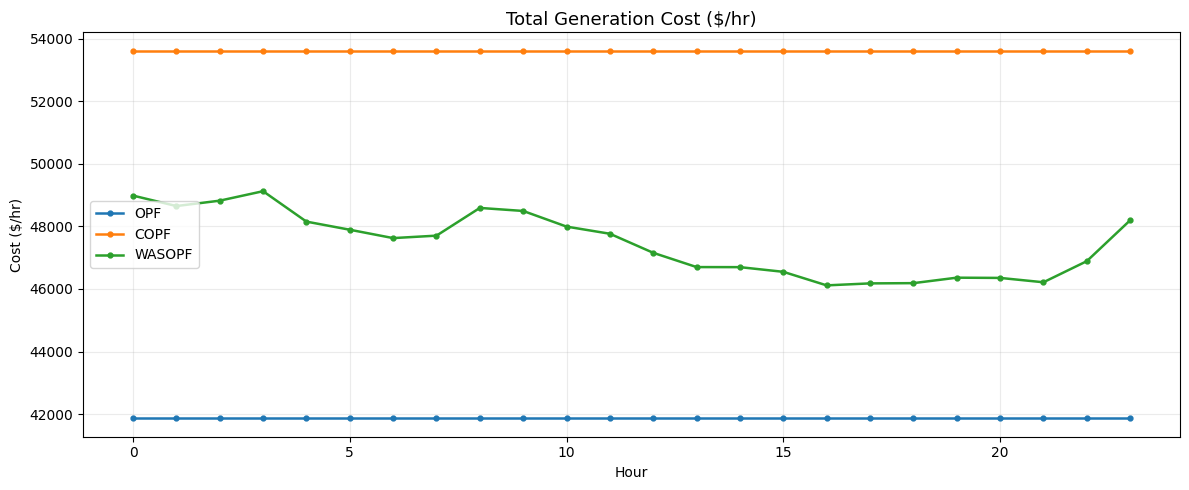

In [21]:
if "cost" in hourly_df.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    for mode in mode_order:
        mode_df = hourly_df[hourly_df["mode"] == mode]
        if mode_df.empty:
            continue
        ax.plot(mode_df["hour"], mode_df["cost"], marker="o", linewidth=1.8,
                markersize=3.5, label=mode, color=color_map.get(mode, None))
    ax.set_title("Total Generation Cost ($/hr)", fontsize=13)
    ax.set_xlabel("Hour")
    ax.set_ylabel("Cost ($/hr)")
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Metric 'cost' not found in hourly results.")


**Significance:** Total generation cost is the primary objective in standard OPF. COPF and WASOPF typically incur higher costs because they impose additional constraints (carbon caps, weather-adaptive thermal limits). The gap between OPF and WASOPF reflects the economic price of environmental and thermal safety compliance. Hours with large cost spikes often coincide with high-demand or poor-weather periods.

### Plot: Hourly Emissions
Compares total CO₂ emissions across all three dispatch modes for each hour.

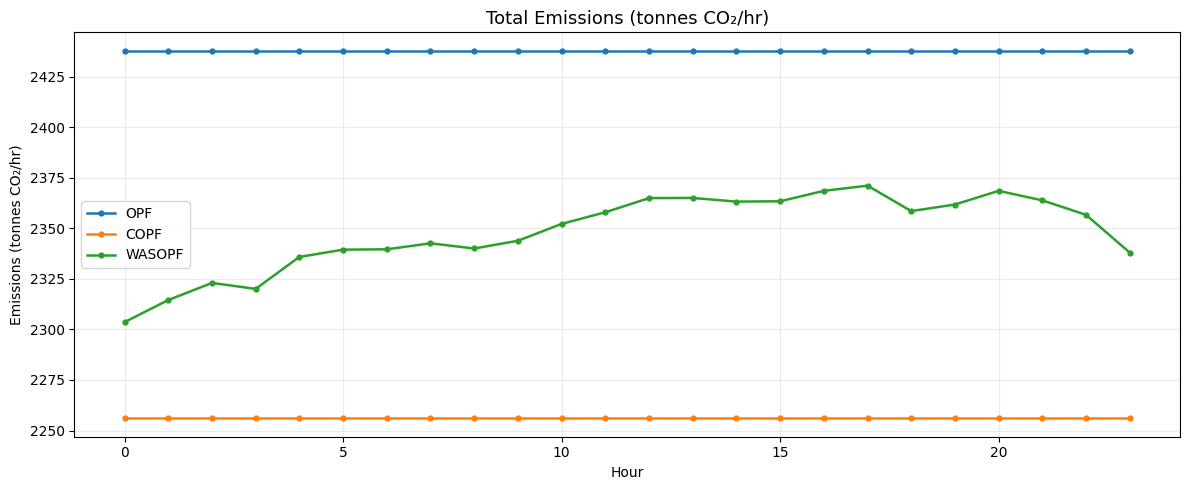

In [22]:
if "emis" in hourly_df.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    for mode in mode_order:
        mode_df = hourly_df[hourly_df["mode"] == mode]
        if mode_df.empty:
            continue
        ax.plot(mode_df["hour"], mode_df["emis"], marker="o", linewidth=1.8,
                markersize=3.5, label=mode, color=color_map.get(mode, None))
    ax.set_title("Total Emissions (tonnes CO₂/hr)", fontsize=13)
    ax.set_xlabel("Hour")
    ax.set_ylabel("Emissions (tonnes CO₂/hr)")
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Metric 'emis' not found in hourly results.")


**Significance:** Emissions reduction is the core objective added by COPF and WASOPF. WASOPF typically achieves the lowest emissions because the MDI-based nodal carbon caps tighten limits at poorly-ventilated buses where pollution impact is highest. Hours where WASOPF emissions dip well below OPF demonstrate the value of weather-aware environmental dispatch.

### Plot: Generator-Level MDI vs Emissions
Plots hourly `MDI_bus` and `Emission_g` for one selected generator (WASOPF) to directly show the weather–emission relationship at that generator node.

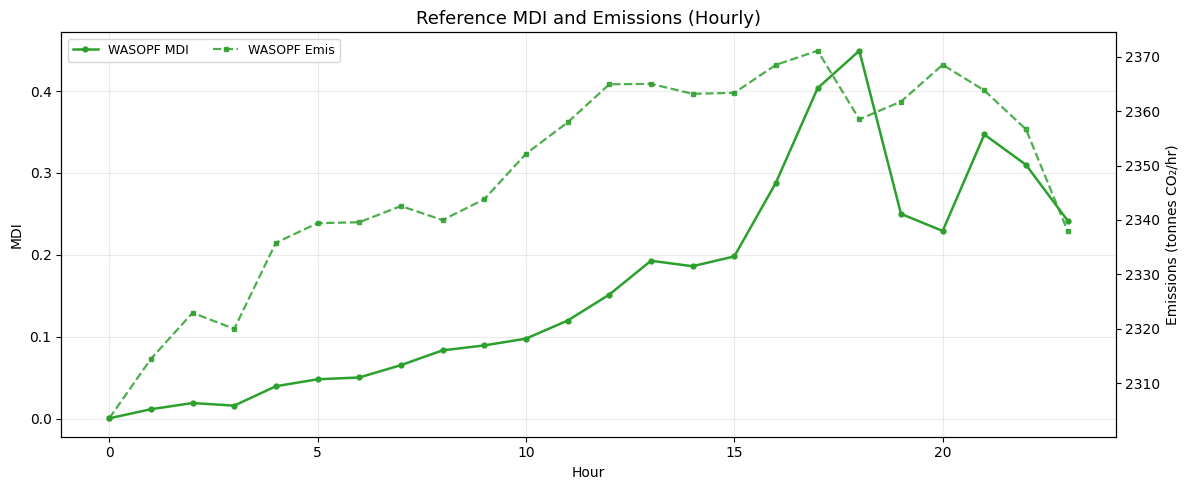

In [23]:
mdi_ok = "mdi_ref" in hourly_df.columns
emis_ok = "emis" in hourly_df.columns

if mdi_ok and emis_ok:
    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax2 = ax1.twinx()
    mode_order = ["WASOPF"]
    for mode in mode_order:
        mode_df = hourly_df[hourly_df["mode"] == mode]
        if mode_df.empty:
            continue

        color = color_map.get(mode, None)
        ax1.plot(
            mode_df["hour"], mode_df["mdi_ref"],
            marker="o", linewidth=1.8, markersize=3.5,
            label=f"{mode} MDI", color=color
        )
        ax2.plot(
            mode_df["hour"], mode_df["emis"],
            marker="s", linestyle="--", linewidth=1.6, markersize=3.2,
            label=f"{mode} Emis", color=color, alpha=0.85
        )

    ax1.set_title("Reference MDI and Emissions (Hourly)", fontsize=13)
    ax1.set_xlabel("Hour")
    ax1.set_ylabel("MDI")
    ax2.set_ylabel("Emissions (tonnes CO₂/hr)")
    ax1.grid(True, alpha=0.25)

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left", ncol=2, fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    missing_metrics = []
    if not mdi_ok:
        missing_metrics.append("mdi_ref")
    if not emis_ok:
        missing_metrics.append("emis")
    print(f"Missing metric(s) in hourly results: {', '.join(missing_metrics)}")


**Significance:** This combined chart links the atmospheric driver (`MDI`) and the environmental outcome (`emis`) in the same hourly frame. Higher MDI implies stronger ventilation, while lower MDI indicates poorer dispersion conditions. In WASOPF, low-MDI hours trigger tighter environmental pressure, so comparing the dashed emissions curves against the MDI trajectories helps verify whether dispatch adaptation is reducing emissions when dispersion is weak.